# Full Network Disruption Analysis

This notebook tells the project as a before-and-after investigation.

We first reconstruct the Montagna organization by merging meetings and phone calls into one interaction network. We then remove the `41` actors flagged as arrested to approximate the immediate shock of the police intervention and ask a second question: what still remains visible once the original core is hit?

The analysis is organized around five reporting goals:

1. rebuild the full network before intervention
2. identify the actors who anchored the original core
3. measure how strongly arrests fragmented the organization
4. rank the surviving actors who now matter most
5. rank the arrested actors most likely to reveal the remnants


## Notebook Roadmap

This notebook is a five-phases story rather than a loose collection of metrics.

- **Phase I:** audit the available evidence and merge the two interaction channels
- **Phase II:** describe the intact organization and highlight its central actors
- **Phase III:** simulate disruption by removing arrested actors and measure the collapse in cohesion
- **Phase IV:** identify the surviving actors who become the clearest follow-up targets
- **Phase V:** identify the arrested actors who can best expose those survivors

In [113]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd
import numpy as np


In [114]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ROLES_PATH = PROJECT_ROOT / 'data/processed/roles.csv'
CALLS_PATH = PROJECT_ROOT / 'data/raw/Montagna_Phone_Calls_Edgelist.csv'
MEETINGS_PATH = PROJECT_ROOT / 'data/raw/Montagna_Meetings_Edgelist.csv'

PROCESSED_DIR = PROJECT_ROOT / 'data/processed'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'

roles = pd.read_csv(ROLES_PATH)
calls_raw = pd.read_csv(CALLS_PATH)
meetings_raw = pd.read_csv(MEETINGS_PATH, sep=r'\s+')

roles.head()

,Node,Role,Relationship,Request,family_role,family,arrested
0,N0,cooperating witness,NaN,NaN,cooperating witness,Unknown,0
1,N1,NaN,conversation with 0,NaN,NaN,NaN,0
2,N2,boss family ''Barcellona Pozzo di Gotto'',NaN,NaN,boss,Barcellona Pozzo di Gotto,0
3,N3,boss family ''Caltagirone'',NaN,NaN,boss,Caltagirone,0
4,N4,enterpreneur,NaN,NaN,enterpreneur,Unknown,0


## Data Audit

Before building the graph, this section checks whether the three source tables cover the same people.

That matters for the story: if interaction data and role metadata overlap well enough, we can move from descriptive network charts to operational questions about leaders, families, disruption, and follow-up targeting.


In [115]:
calls_nodes = set(calls_raw['Source']).union(calls_raw['Target'])
meetings_nodes = set(meetings_raw['Source']).union(meetings_raw['Target'])
role_nodes = set(roles['Node'])
network_nodes = calls_nodes.union(meetings_nodes)

pd.DataFrame(
    {
        'dataset': ['roles', 'calls', 'meetings', 'combined_interactions'],
        'rows_or_edges': [len(roles), len(calls_raw), len(meetings_raw), len(calls_raw) + len(meetings_raw)],
        'unique_nodes': [len(role_nodes), len(calls_nodes), len(meetings_nodes), len(network_nodes)],
        'nodes_with_role_metadata': [len(role_nodes), len(calls_nodes & role_nodes), len(meetings_nodes & role_nodes), len(network_nodes & role_nodes)],
    }
)

,dataset,rows_or_edges,unique_nodes,nodes_with_role_metadata
0,roles,143,143,143
1,calls,150,95,94
2,meetings,289,95,94
3,combined_interactions,439,144,142


## Helper Functions

These helpers keep the workflow reproducible and make the notebook easier to read as a finished analysis rather than an exploration scratchpad.


In [116]:
def prepare_calls_edges(calls_df):
    edges = calls_df.copy()
    edges['Weight'] = pd.to_numeric(edges['Weight'], errors='coerce').fillna(0)
    edges['channel'] = 'call'
    edges['call_weight'] = edges['Weight']
    edges['meeting_weight'] = 0
    return edges[['Source', 'Target', 'Weight', 'channel', 'call_weight', 'meeting_weight']]


def prepare_meeting_edges(meetings_df):
    edges = meetings_df.copy()
    edges['Weight'] = pd.to_numeric(edges['Weight'], errors='coerce').fillna(0)
    edges['channel'] = 'meeting'
    edges['call_weight'] = 0
    edges['meeting_weight'] = edges['Weight']

    reverse_edges = edges.rename(columns={'Source': 'Target', 'Target': 'Source'})
    directed_edges = pd.concat([edges, reverse_edges], ignore_index=True)
    return directed_edges[['Source', 'Target', 'Weight', 'channel', 'call_weight', 'meeting_weight']]


def combine_edge_tables(calls_edges, meeting_edges):
    all_edges = pd.concat([calls_edges, meeting_edges], ignore_index=True)
    combined = (
        all_edges.groupby(['Source', 'Target'], as_index=False)
        .agg(
            weight=('Weight', 'sum'),
            call_weight=('call_weight', 'sum'),
            meeting_weight=('meeting_weight', 'sum'),
            channels=('channel', lambda x: '+'.join(sorted(set(x)))),
        )
    )
    combined['edge_type'] = combined['channels'].map(lambda x: 'both' if '+' in x else x)
    return combined.sort_values(['Source', 'Target']).reset_index(drop=True)


def build_graph(edge_table, node_table):
    graph = nx.DiGraph()

    for row in node_table.to_dict('records'):
        node_id = row.pop('Node')
        graph.add_node(node_id, **row)

    for row in edge_table.to_dict('records'):
        graph.add_edge(
            row['Source'],
            row['Target'],
            weight=float(row['weight']),
            call_weight=float(row['call_weight']),
            meeting_weight=float(row['meeting_weight']),
            edge_type=row['edge_type'],
        )

    return graph


def summarize_graph(graph):
    if graph.number_of_nodes() == 0:
        return pd.Series({'nodes': 0, 'edges': 0, 'isolates': 0, 'weak_components': 0, 'largest_weak_component': 0, 'density': 0.0})

    weak_components = list(nx.weakly_connected_components(graph))
    return pd.Series(
        {
            'nodes': graph.number_of_nodes(),
            'edges': graph.number_of_edges(),
            'isolates': len(list(nx.isolates(graph))),
            'weak_components': len(weak_components),
            'largest_weak_component': max(len(component) for component in weak_components),
            'density': nx.density(graph),
        }
    )


def compute_node_metrics(graph):
    undirected_graph = graph.to_undirected()
    distance_graph = graph.copy()
    for source, target, data in distance_graph.edges(data=True):
        weight = data.get('weight', 0) or 0
        data['distance'] = 1 / weight if weight > 0 else 10**9

    try:
        pagerank = nx.pagerank(graph, weight='weight')
    except ModuleNotFoundError:
        from networkx.algorithms.link_analysis.pagerank_alg import _pagerank_python

        pagerank = _pagerank_python(graph, weight='weight')
    betweenness = nx.betweenness_centrality(distance_graph, weight='distance', normalized=True)
    in_strength = dict(graph.in_degree(weight='weight'))
    out_strength = dict(graph.out_degree(weight='weight'))
    weighted_degree = dict(undirected_graph.degree(weight='weight'))
    degree = dict(undirected_graph.degree())

    weak_components = list(nx.weakly_connected_components(graph))
    component_lookup = {}
    component_size_lookup = {}
    for component_id, component_nodes in enumerate(sorted(weak_components, key=len, reverse=True), start=1):
        for node in component_nodes:
            component_lookup[node] = component_id
            component_size_lookup[node] = len(component_nodes)

    metrics = pd.DataFrame({'Node': list(graph.nodes())})
    metrics['degree'] = metrics['Node'].map(degree).fillna(0)
    metrics['weighted_degree'] = metrics['Node'].map(weighted_degree).fillna(0.0)
    metrics['in_strength'] = metrics['Node'].map(in_strength).fillna(0.0)
    metrics['out_strength'] = metrics['Node'].map(out_strength).fillna(0.0)
    metrics['pagerank'] = metrics['Node'].map(pagerank).fillna(0.0)
    metrics['betweenness'] = metrics['Node'].map(betweenness).fillna(0.0)
    metrics['weak_component'] = metrics['Node'].map(component_lookup).fillna(-1).astype(int)
    metrics['weak_component_size'] = metrics['Node'].map(component_size_lookup).fillna(1).astype(int)
    return metrics.sort_values(['pagerank', 'weighted_degree'], ascending=False).reset_index(drop=True)


def score_family_role(role_text):
    if pd.isna(role_text):
        return 0

    role_text = str(role_text).lower()
    if 'boss' in role_text and 'deputy' not in role_text:
        return 5
    if 'co-founder' in role_text or 'deputy boss' in role_text:
        return 4
    if 'executive' in role_text:
        return 3
    if 'member' in role_text:
        return 2
    return 1


def compute_neighbor_features(graph, node_table):
    family_lookup = node_table.set_index('Node')['family'].to_dict()
    arrested_lookup = node_table.set_index('Node')['arrested'].to_dict()
    rows = []

    for node in graph.nodes():
        neighbors = set(graph.predecessors(node)).union(graph.successors(node))
        surviving_neighbors = {neighbor for neighbor in neighbors if arrested_lookup.get(neighbor, 0) == 0}

        focal_family = family_lookup.get(node, 'Unknown')
        cross_family_neighbors = {
            neighbor
            for neighbor in neighbors
            if family_lookup.get(neighbor, 'Unknown') not in {focal_family, 'Unknown'}
        }

        rows.append(
            {
                'Node': node,
                'neighbor_count': len(neighbors),
                'surviving_neighbor_count': len(surviving_neighbors),
                'cross_family_reach': len(cross_family_neighbors),
            }
        )

    return pd.DataFrame(rows)


## Phase I. The Criminal Organization

(A rebuilding before intervention) Meetings are converted into reciprocal directed edges so they can be merged with the directed call network. The result is one communication graph that captures both face-to-face coordination and remote contact.


In [117]:
calls_edges = prepare_calls_edges(calls_raw)
meeting_edges = prepare_meeting_edges(meetings_raw)
combined_edges = combine_edge_tables(calls_edges, meeting_edges)

full_graph = build_graph(combined_edges, roles)
full_visual_graph = full_graph.to_undirected()

combined_edges.head()


,Source,Target,weight,call_weight,meeting_weight,channels,edge_type
0,N0,N1,1,0,1,meeting,meeting
1,N0,N2,1,0,1,meeting,meeting
2,N1,N0,1,0,1,meeting,meeting
3,N1,N2,1,0,1,meeting,meeting
4,N10,N11,1,0,1,meeting,meeting


In [118]:
pd.DataFrame(
    {
        'table': ['calls_edges', 'meeting_edges_directed', 'combined_edges'],
        'rows': [len(calls_edges), len(meeting_edges), len(combined_edges)],
        'unique_sources': [calls_edges['Source'].nunique(), meeting_edges['Source'].nunique(), combined_edges['Source'].nunique()],
        'unique_targets': [calls_edges['Target'].nunique(), meeting_edges['Target'].nunique(), combined_edges['Target'].nunique()],
    }
)

,table,rows,unique_sources,unique_targets
0,calls_edges,150,63,65
1,meeting_edges_directed,578,95,95
2,combined_edges,583,123,123


## Phase II. The Organization Before The Crackdown

This baseline uses every actor in the processed role table and every observed interaction from both channels. The goal is to reveal the network's original center of gravity before disruption is simulated.


In [119]:
full_summary = summarize_graph(full_graph)
full_metrics = compute_node_metrics(full_graph)
neighbor_features = compute_neighbor_features(full_graph, roles)

full_metrics = (
    full_metrics
    .merge(roles, on='Node', how='left')
    .merge(neighbor_features, on='Node', how='left')
)
full_metrics['role_priority_score'] = full_metrics['family_role'].apply(score_family_role)

full_summary.to_frame('value')

,value
nodes,145.000000
edges,583.000000
isolates,1.000000
weak_components,6.000000
largest_weak_component,135.000000
density,0.027921


In [120]:
full_metrics[
    ['Node', 'family_role', 'family', 'arrested', 'pagerank', 'betweenness', 'weighted_degree', 'neighbor_count', 'cross_family_reach']
].head(15)

,Node,family_role,family,arrested,pagerank,betweenness,weighted_degree,neighbor_count,cross_family_reach
0,N18,executive,Mistretta,1.0,0.054437,0.305511,85.0,40,16
1,N47,deputy boss,Batanesi,1.0,0.047491,0.238572,103.0,27,9
2,N68,executive,Batanesi,1.0,0.033258,0.124960,54.0,25,6
3,N61,executive,Mistretta,1.0,0.033255,0.095862,33.0,18,8
4,N27,executive,Batanesi,1.0,0.032027,0.077538,55.0,19,8
5,N22,Pharmacist-member,Unknown,1.0,0.030940,0.114680,45.0,17,9
6,N29,enterpreneur,Unknown,1.0,0.029000,0.211976,46.0,16,8
7,N12,member,Mistretta,1.0,0.027097,0.080198,35.0,16,6
8,N45,member,Batanesi,1.0,0.025866,0.039854,49.0,14,5
9,N89,member,Batanesi,1.0,0.024815,0.019716,46.0,11,2


In [121]:
edge_widths = [
    full_visual_graph[u][v].get('weight', 1) * 0.2
    for u, v in full_visual_graph.edges()
]


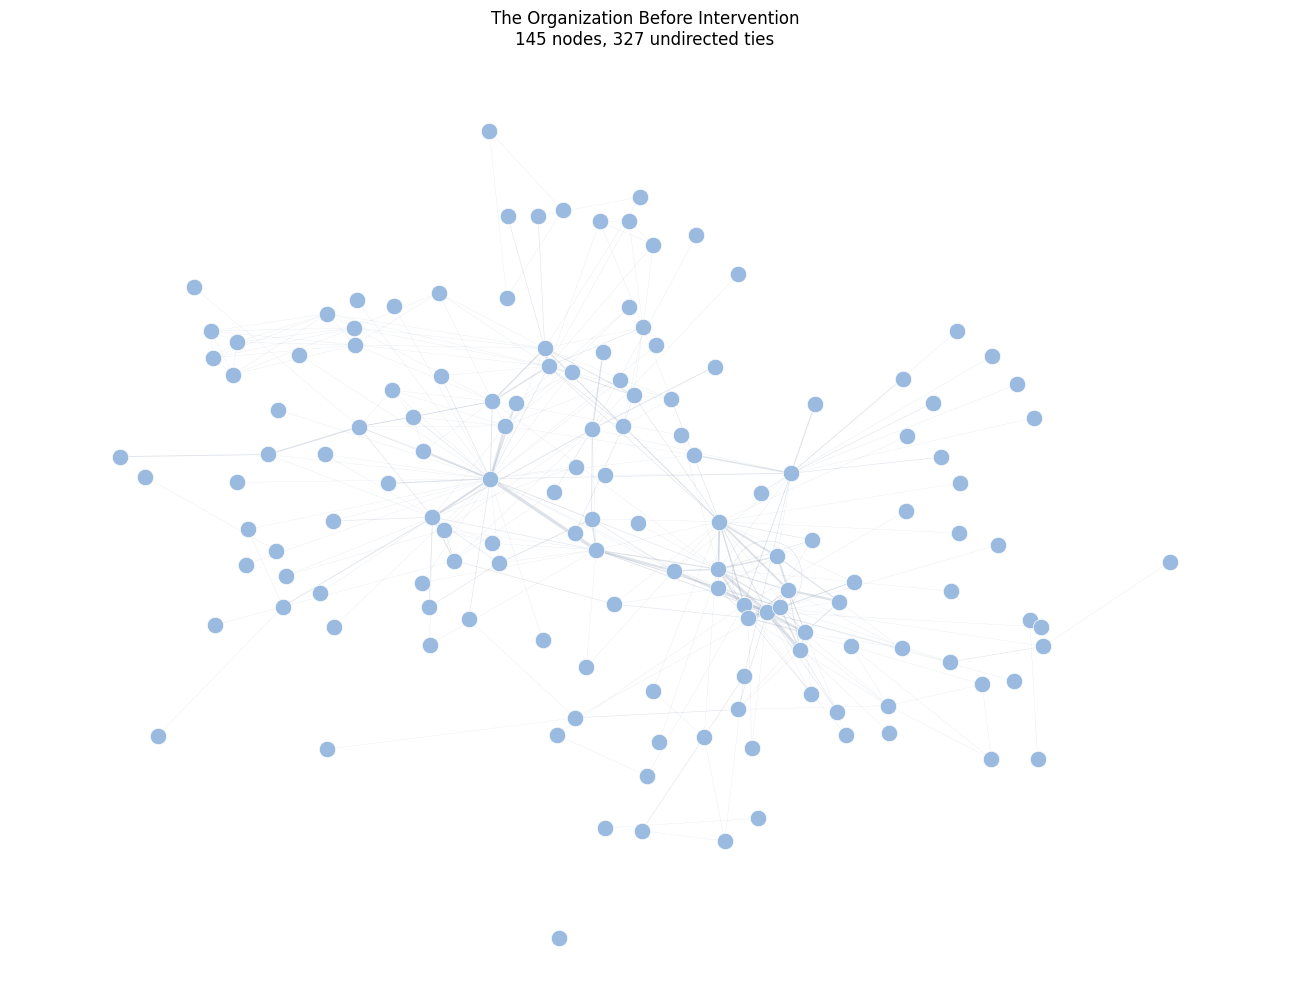

In [122]:
n = full_visual_graph.number_of_nodes()

full_network_position = nx.spring_layout(
    full_visual_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(
    full_visual_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=edge_widths,
)
nx.draw_networkx_nodes(
    full_visual_graph,
    pos=full_network_position,
    node_color="#9abae0",
    node_size=140,
    edgecolors="white",
    linewidths=0.5,
)

plt.title(
    f"The Organization Before Intervention\n{full_visual_graph.number_of_nodes()} nodes, {full_visual_graph.number_of_edges()} undirected ties"
)
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'initial_network.png')
plt.show()


## Who Anchored The Original Core?

The next two cells turn the top-ranked actors into characters in the story. The table identifies who dominates the baseline network, and the ego-network plots show the local neighborhoods that made those actors structurally important.


In [123]:
top3_nodes = full_metrics.sort_values(['pagerank', 'weighted_degree'], ascending=False).head(3)['Node'].tolist()

ego_summary_rows = []
for node in top3_nodes:
    ego_graph = nx.ego_graph(full_graph.to_undirected(), node, radius=1)
    ego_summary_rows.append(
        {
            'Node': node,
            'family_role': roles.set_index('Node').get('family_role', pd.Series()).get(node, pd.NA),
            'family': roles.set_index('Node').get('family', pd.Series()).get(node, pd.NA),
            'ego_nodes': ego_graph.number_of_nodes(),
            'ego_edges': ego_graph.number_of_edges(),
        }
    )

pd.DataFrame(ego_summary_rows)

,Node,family_role,family,ego_nodes,ego_edges
0,N18,executive,Mistretta,41,90
1,N47,deputy boss,Batanesi,27,82
2,N68,executive,Batanesi,26,74


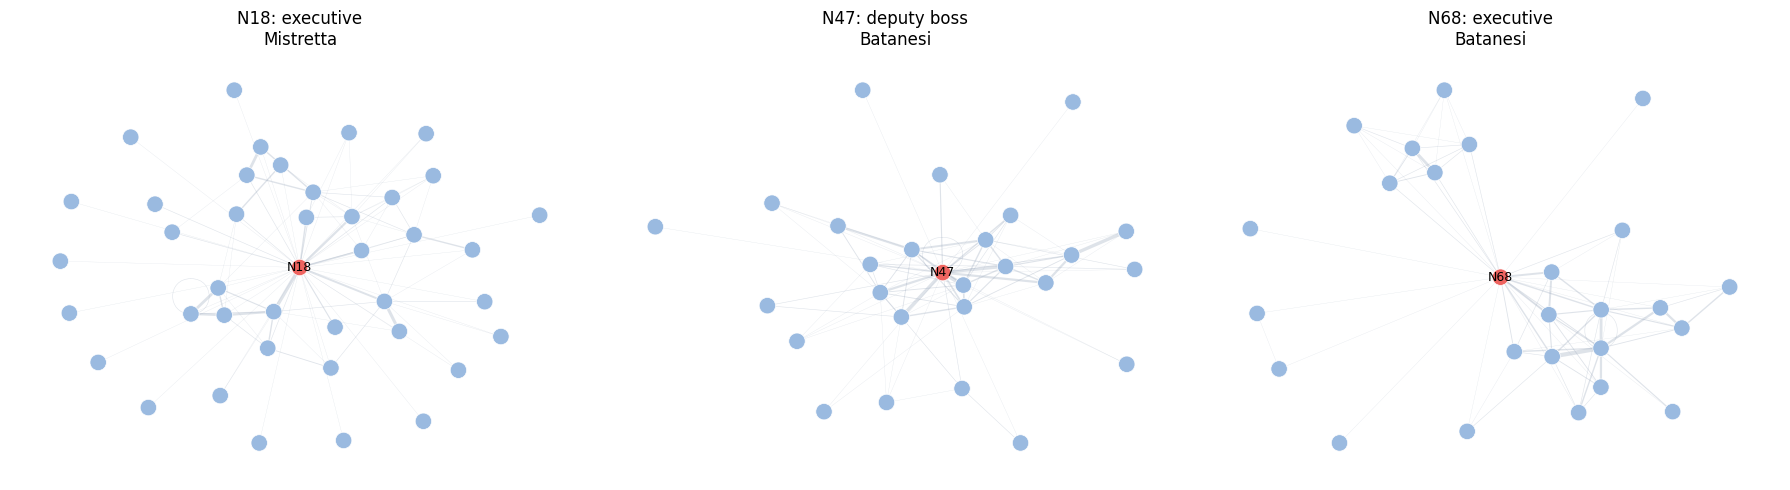

In [124]:
family_lookup = roles.set_index('Node')['family'].to_dict()
role_lookup = roles.set_index('Node')['family_role'].to_dict()

fig, axes = plt.subplots(1, len(top3_nodes), figsize=(6 * max(len(top3_nodes), 1), 5))
axes = [axes] if len(top3_nodes) == 1 else axes

for axis, node in zip(axes, top3_nodes):
    ego_graph = nx.ego_graph(full_graph.to_undirected(), node, radius=1)

    n = ego_graph.number_of_nodes()
    position = nx.spring_layout(
        ego_graph,
        seed=42,
        weight="weight",
        k=1 / np.sqrt(n),
        iterations=300
    )

    node_colors = [
        "#ee6460" if ego_node == node else "#9abae0"
        for ego_node in ego_graph.nodes()
    ]

    ego_edge_widths = [
        ego_graph[u][v].get('weight', 1) * 0.2
        for u, v in ego_graph.edges()
    ]

    nx.draw_networkx_edges(
        ego_graph,
        pos=position,
        ax=axis,
        edge_color="#94a3b8",
        alpha=0.30,
        width=ego_edge_widths,
    )

    nx.draw_networkx_nodes(
        ego_graph,
        pos=position,
        ax=axis,
        node_color=node_colors,
        node_size=140,
        edgecolors="white",
        linewidths=0.5,
    )

    labels = {ego_node: ego_node if ego_node == node else "" for ego_node in ego_graph.nodes()}

    nx.draw_networkx_labels(
        ego_graph,
        pos=position,
        labels=labels,
        font_size=9,
        font_color="black",
        ax=axis,
    )

    family = family_lookup.get(node, "Unknown")
    family_role = role_lookup.get(node, "Unknown")
    axis.set_title(f"{node}: {family_role}\n{family}")
    axis.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top3_actors.png')
plt.show()


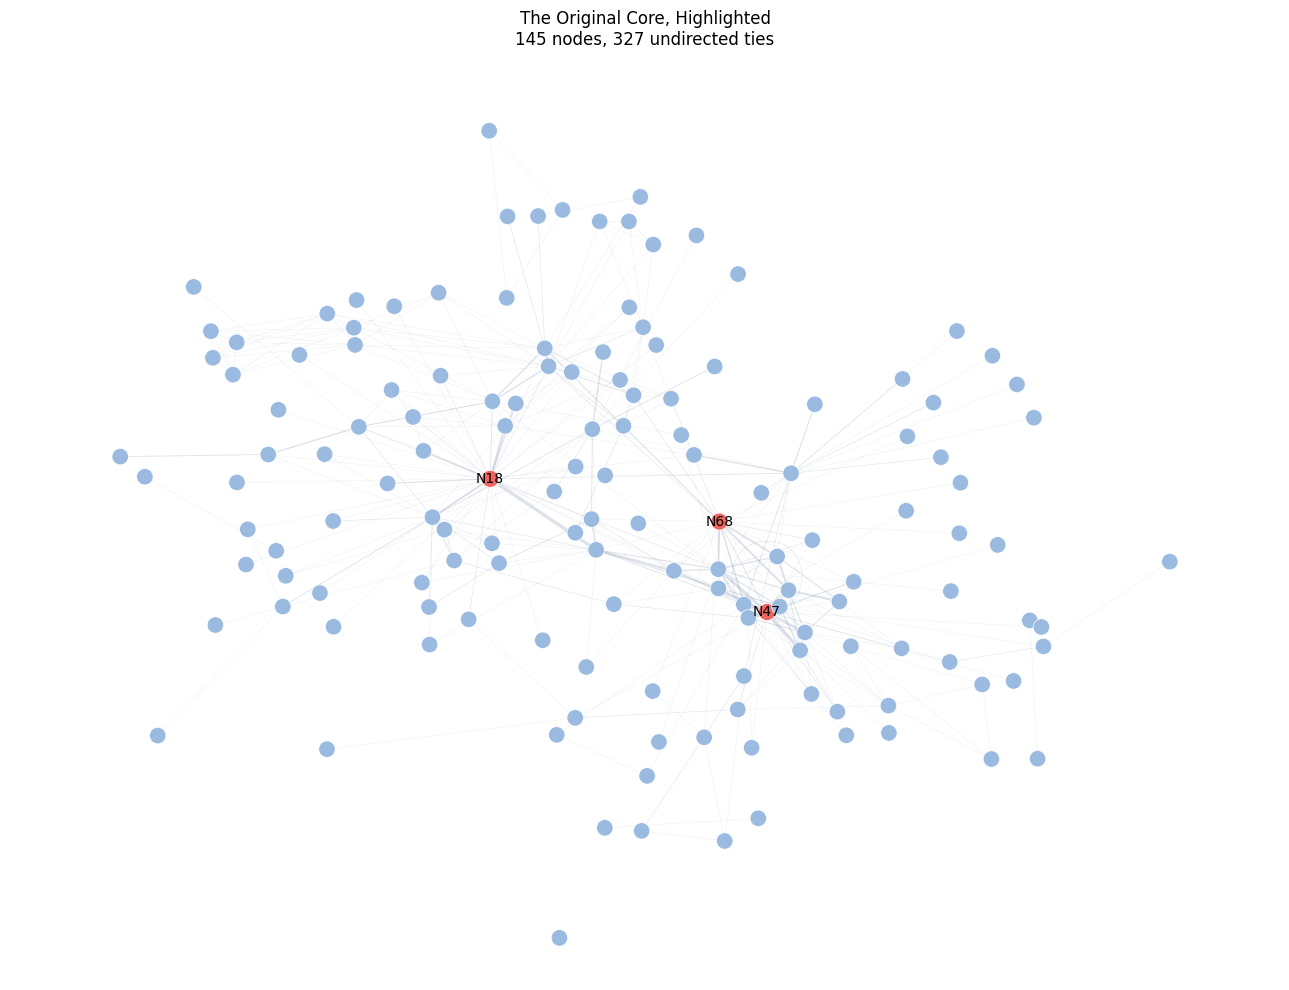

In [125]:
node_colors = [
    "#ee6460" if node in top3_nodes else "#9abae0"
    for node in full_visual_graph.nodes()
]

node_sizes = [
    150 if node in top3_nodes else 140
    for node in full_visual_graph.nodes()
]

labels = {
    node: node if node in top3_nodes else ""
    for node in full_visual_graph.nodes()
}

n = full_visual_graph.number_of_nodes()
full_network_position = nx.spring_layout(
    full_visual_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

plt.figure(figsize=(13, 10))

nx.draw_networkx_edges(
    full_visual_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=edge_widths,
)

nx.draw_networkx_nodes(
    full_visual_graph,
    pos=full_network_position,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=0.5,
)

nx.draw_networkx_labels(
    full_visual_graph,
    pos=full_network_position,
    labels=labels,
    font_size=10,
    font_color="black"
)

plt.title(
    f"The Original Core, Highlighted\n{full_visual_graph.number_of_nodes()} nodes, {full_visual_graph.number_of_edges()} undirected ties"
)

plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top3_highlighted.png')
plt.show()


## Phase III. The Intervention Hits The Core

The metadata flags `41` actors as arrested. In this notebook, those nodes are removed entirely to approximate the immediate structural shock of the intervention.

This is a deliberate simplification, but it is a useful one: it lets us compare the intact organization with the residual network and ask whether the crackdown merely reduced the network or actually broke its cohesion.


In [128]:
arrested_nodes = roles.loc[roles['arrested'] == 1, 'Node'].tolist()

node_colors_arrested = [
    "#2a9d8f" if node in arrested_nodes else "#9abae0"
    for node in full_visual_graph.nodes()
]

arrested_nodes

['N12',
 'N18',
 'N19',
 'N21',
 'N22',
 'N23',
 'N25',
 'N27',
 'N29',
 'N33',
 'N36',
 'N43',
 'N45',
 'N47',
 'N48',
 'N49',
 'N50',
 'N51',
 'N52',
 'N54',
 'N61',
 'N62',
 'N63',
 'N64',
 'N66',
 'N67',
 'N68',
 'N70',
 'N75',
 'N76',
 'N77',
 'N80',
 'N85',
 'N89',
 'N96',
 'N97',
 'N99',
 'N128',
 'N149',
 'N150',
 'N151']

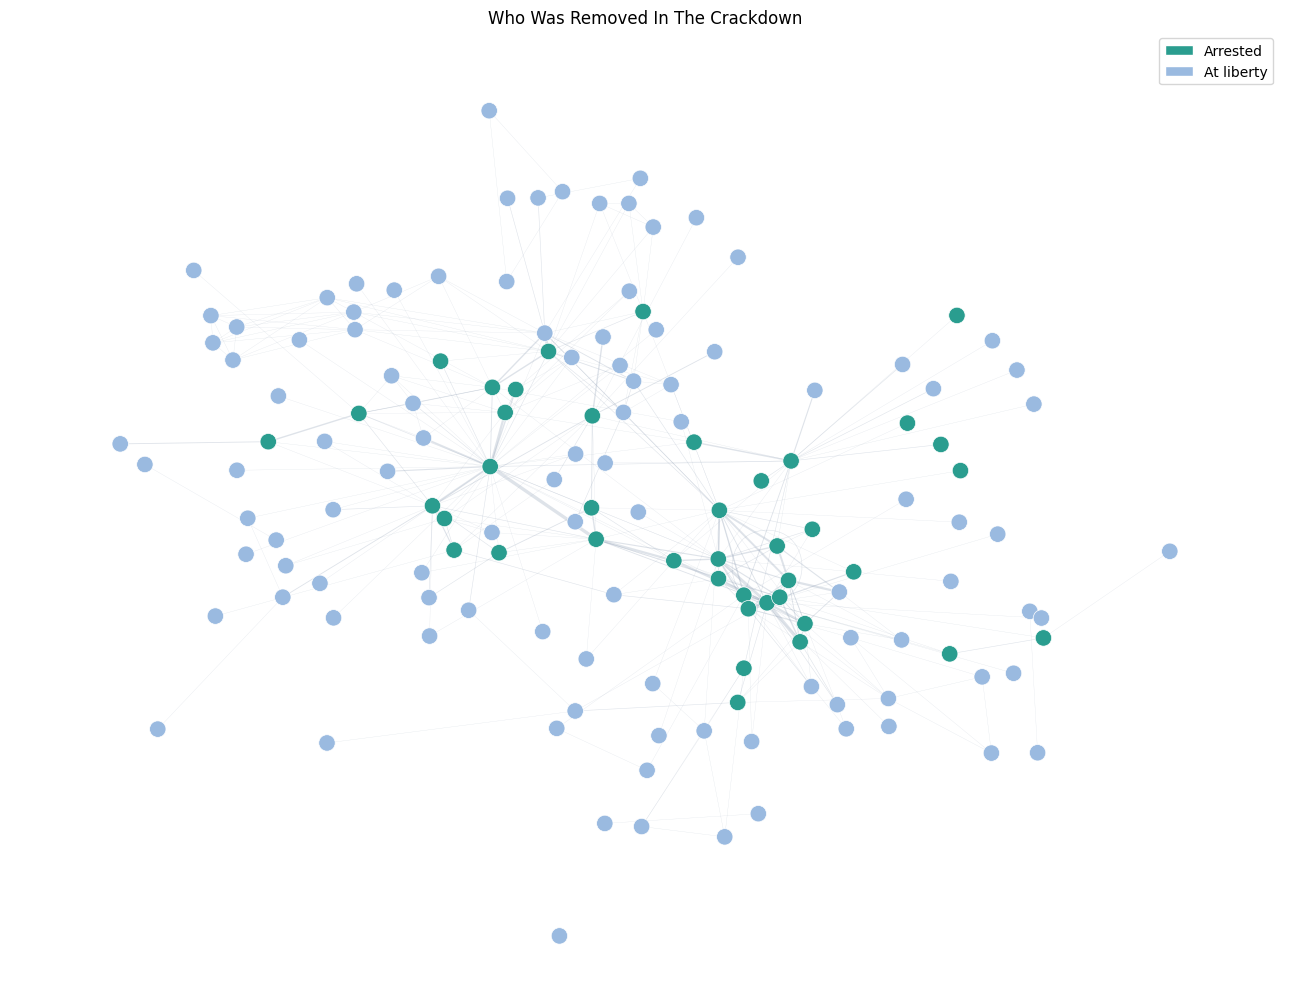

In [129]:
n = full_visual_graph.number_of_nodes()

full_network_position = nx.spring_layout(
    full_visual_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(
    full_visual_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=edge_widths,
)
nx.draw_networkx_nodes(
    full_visual_graph,
    pos=full_network_position,
    node_color=node_colors_arrested,
    node_size=140,
    edgecolors="white",
    linewidths=0.5,
)

legend_elements = [
    Patch(facecolor="#2a9d8f", edgecolor="white", label="Arrested"),
    Patch(facecolor="#9abae0", edgecolor="white", label="At liberty"),
]

plt.title("Who Was Removed In The Crackdown")
plt.legend(handles=legend_elements, loc="upper right")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'arrests_network.png')
plt.show()


## What Survives After Disruption?

Once the arrested actors are removed, the analysis shifts from describing the old organization to measuring the residual one. The key question is no longer who mattered before the crackdown, but what kind of structure is still left behind.


In [130]:
disrupted_graph = full_graph.copy()
disrupted_graph.remove_nodes_from(arrested_nodes)

disrupted_summary = summarize_graph(disrupted_graph)
disrupted_metrics = compute_node_metrics(disrupted_graph).merge(roles, on='Node', how='left')

network_disruption_scorecard = pd.DataFrame(
    {
        'metric': [
            'nodes',
            'directed_ties',
            'isolates',
            'weak_components',
            'largest_weak_component',
            'density',
        ],
        'before_intervention': [
            full_summary['nodes'],
            full_summary['edges'],
            full_summary['isolates'],
            full_summary['weak_components'],
            full_summary['largest_weak_component'],
            full_summary['density'],
        ],
        'after_removing_arrested_actors': [
            disrupted_summary['nodes'],
            disrupted_summary['edges'],
            disrupted_summary['isolates'],
            disrupted_summary['weak_components'],
            disrupted_summary['largest_weak_component'],
            disrupted_summary['density'],
        ],
    }
)
network_disruption_scorecard['absolute_change'] = (
    network_disruption_scorecard['after_removing_arrested_actors']
    - network_disruption_scorecard['before_intervention']
)
network_disruption_scorecard['pct_change'] = np.where(
    network_disruption_scorecard['before_intervention'] != 0,
    network_disruption_scorecard['absolute_change'] / network_disruption_scorecard['before_intervention'],
    np.nan,
)
network_disruption_scorecard.round(4)


,metric,before_intervention,after_removing_arrested_actors,absolute_change,pct_change
0,nodes,145.0000,104.0000,-41.0000,-0.2828
1,directed_ties,583.0000,122.0000,-461.0000,-0.7907
2,isolates,1.0000,55.0000,54.0000,54.0000
3,weak_components,6.0000,68.0000,62.0000,10.3333
4,largest_weak_component,135.0000,16.0000,-119.0000,-0.8815
5,density,0.0279,0.0114,-0.0165,-0.5921


In [131]:
current_status = full_metrics.merge(
    disrupted_metrics[['Node', 'pagerank', 'betweenness', 'weighted_degree', 'weak_component_size']].rename(
        columns={
            'pagerank': 'current_pagerank',
            'betweenness': 'current_betweenness',
            'weighted_degree': 'current_weighted_degree',
            'weak_component_size': 'current_component_size',
        }
    ),
    on='Node',
    how='left',
)

family_disruption_summary = (
    roles.assign(family=roles['family'].fillna('Unspecified'))
    .groupby('family', as_index=False)
    .agg(
        total_members=('Node', 'count'),
        arrested_members=('arrested', 'sum'),
    )
)
family_disruption_summary['surviving_members'] = (
    family_disruption_summary['total_members'] - family_disruption_summary['arrested_members']
)
family_disruption_summary['arrest_rate'] = (
    family_disruption_summary['arrested_members'] / family_disruption_summary['total_members']
)
family_disruption_summary = family_disruption_summary.sort_values(
    ['arrested_members', 'arrest_rate', 'total_members'],
    ascending=[False, False, False],
).reset_index(drop=True)

family_disruption_summary.head(10)


,family,total_members,arrested_members,surviving_members,arrest_rate
0,Unknown,48,17,31,0.354167
1,Batanesi,17,13,4,0.764706
2,Mistretta,9,6,3,0.666667
3,Unspecified,59,5,54,0.084746
4,Mazzaroti,3,0,3,0.000000
5,Barcellona Pozzo di Gotto,2,0,2,0.000000
6,Tortorici,2,0,2,0.000000
7,Brancaccio,1,0,1,0.000000
8,Caltagirone,1,0,1,0.000000
9,San Mauro Castelverde,1,0,1,0.000000


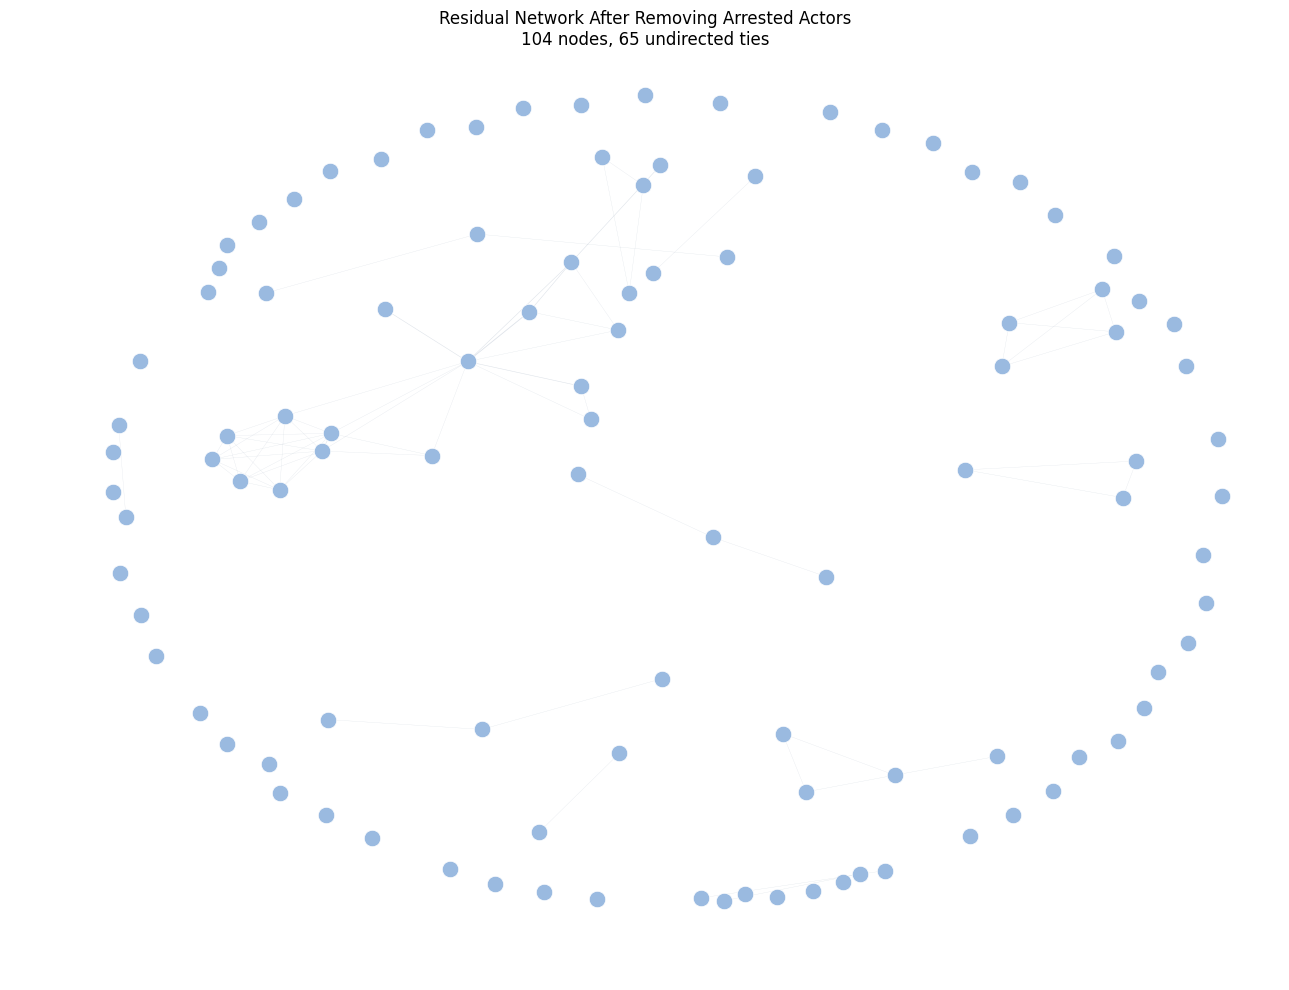

In [132]:
ud_disrupted_graph = disrupted_graph.to_undirected()

n = ud_disrupted_graph.number_of_nodes()

full_network_position = nx.spring_layout(
    ud_disrupted_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

residual_edge_widths = [
    ud_disrupted_graph[u][v].get('weight', 1) * 0.2
    for u, v in ud_disrupted_graph.edges()
]

plt.figure(figsize=(13, 10))
nx.draw_networkx_edges(
    ud_disrupted_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=residual_edge_widths,
)
nx.draw_networkx_nodes(
    ud_disrupted_graph,
    pos=full_network_position,
    node_color="#9abae0",
    node_size=140,
    edgecolors="white",
    linewidths=0.5,
)

plt.title(
    f"Residual Network After Removing Arrested Actors\n{ud_disrupted_graph.number_of_nodes()} nodes, {ud_disrupted_graph.number_of_edges()} undirected ties"
)
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'disrupted_graph.png')
plt.show()


## Phase IV. Which Surviving Actors Matter Most Now?

This ranking focuses on actors who remain at liberty. It combines their importance in the original network with their prominence in the post-disruption network, so the shortlist reflects both legacy influence and present-day structural relevance.


In [133]:
surviving_priority = current_status.loc[current_status['arrested'] == 0].copy()
surviving_priority['current_pagerank'] = surviving_priority['current_pagerank'].fillna(0.0)
surviving_priority['current_weighted_degree'] = surviving_priority['current_weighted_degree'].fillna(0.0)

for column in ['pagerank', 'betweenness', 'current_pagerank', 'current_weighted_degree', 'role_priority_score']:
    surviving_priority[f'{column}_pct'] = surviving_priority[column].rank(pct=True, method='average')

surviving_priority['future_arrest_priority_score'] = (
    0.25 * surviving_priority['pagerank_pct']
    + 0.20 * surviving_priority['betweenness_pct']
    + 0.25 * surviving_priority['current_pagerank_pct']
    + 0.20 * surviving_priority['current_weighted_degree_pct']
    + 0.10 * surviving_priority['role_priority_score_pct']
)

surviving_priority = surviving_priority.sort_values('future_arrest_priority_score', ascending=False)
surviving_priority[
    ['Node', 'family_role', 'family', 'pagerank', 'current_pagerank', 'current_weighted_degree', 'current_component_size', 'future_arrest_priority_score']
].head(5)


,Node,family_role,family,pagerank,current_pagerank,current_weighted_degree,current_component_size,future_arrest_priority_score
10,N11,boss Cosa Nostra in Messina,Unknown,0.023814,0.038438,15.0,16.0,0.997059
38,N3,boss,Caltagirone,0.007859,0.022930,7.0,16.0,0.929412
23,N6,NaN,NaN,0.010151,0.029054,9.0,16.0,0.906863
22,N5,NaN,NaN,0.010151,0.029054,9.0,16.0,0.906863
41,N79,enterpreneur,Unknown,0.007129,0.029646,3.0,4.0,0.890196


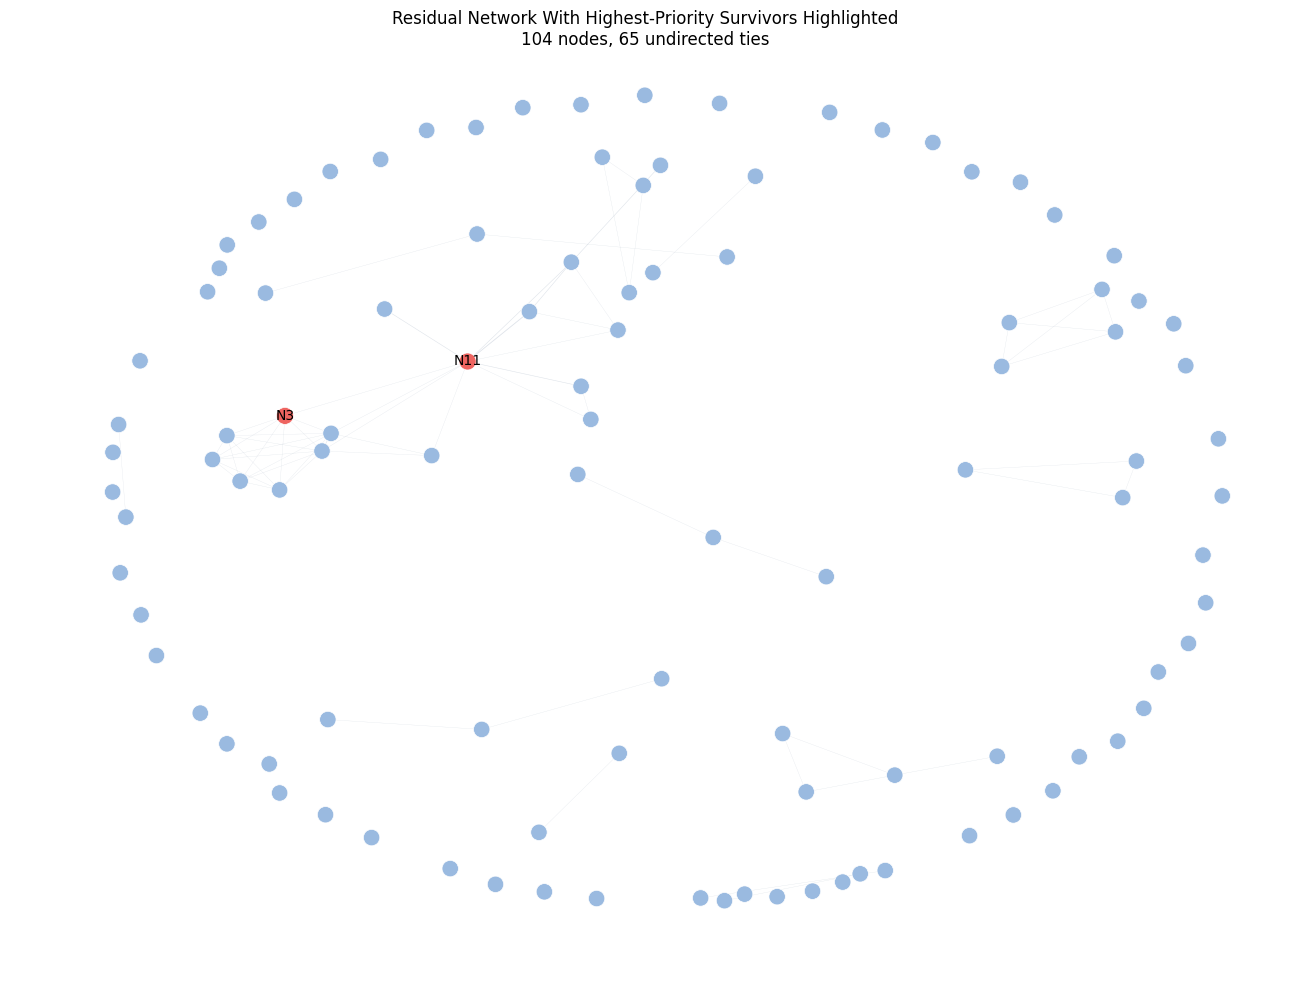

In [134]:
top_survivors = surviving_priority.head(2)['Node'].tolist()

n = ud_disrupted_graph.number_of_nodes()

full_network_position = nx.spring_layout(
    ud_disrupted_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

residual_edge_widths = [
    ud_disrupted_graph[u][v].get('weight', 1) * 0.2
    for u, v in ud_disrupted_graph.edges()
]

node_colors = [
    "#ee6460" if node in top_survivors else "#9abae0"
    for node in ud_disrupted_graph.nodes()
]

node_sizes = [
    150 if node in top_survivors else 140
    for node in ud_disrupted_graph.nodes()
]

labels = {
    node: node if node in top_survivors else ""
    for node in ud_disrupted_graph.nodes()
}

plt.figure(figsize=(13, 10))

nx.draw_networkx_edges(
    ud_disrupted_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=residual_edge_widths,
)

nx.draw_networkx_nodes(
    ud_disrupted_graph,
    pos=full_network_position,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=0.5,
)

nx.draw_networkx_labels(
    ud_disrupted_graph,
    pos=full_network_position,
    labels=labels,
    font_size=10,
    font_color="black"
)

plt.title(
    f"Residual Network With Highest-Priority Survivors Highlighted\n{ud_disrupted_graph.number_of_nodes()} nodes, {ud_disrupted_graph.number_of_edges()} undirected ties"
)
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'disrupted_graph_most_wanted.png')
plt.show()


The shortlist is led by `N11` and `N3`. In story terms, they are the clearest examples of actors who become easier to isolate once the original core has been removed: one is the **boss of Cosa Nostra in Messina**, the other the **boss of the Caltagirone family**.


## Phase V. Which Arrested Actors Can Still Expose The Remnants?

This ranking focuses on arrested actors only. The score combines baseline centrality, family status, surviving-neighbor access, and cross-family reach so the result can be interpreted as intelligence value rather than just historical importance.


In [135]:
arrested_priority = full_metrics.loc[full_metrics['arrested'] == 1].copy()

for column in ['pagerank', 'betweenness', 'surviving_neighbor_count', 'cross_family_reach', 'role_priority_score']:
    arrested_priority[f'{column}_pct'] = arrested_priority[column].rank(pct=True, method='average')

arrested_priority['interrogation_priority_score'] = (
    0.30 * arrested_priority['pagerank_pct']
    + 0.25 * arrested_priority['betweenness_pct']
    + 0.20 * arrested_priority['surviving_neighbor_count_pct']
    + 0.15 * arrested_priority['cross_family_reach_pct']
    + 0.10 * arrested_priority['role_priority_score_pct']
)

arrested_priority = arrested_priority.sort_values('interrogation_priority_score', ascending=False)
arrested_priority[
    ['Node', 'family_role', 'family', 'pagerank', 'betweenness', 'surviving_neighbor_count', 'cross_family_reach', 'interrogation_priority_score']
].head(10)


,Node,family_role,family,pagerank,betweenness,surviving_neighbor_count,cross_family_reach,interrogation_priority_score
0,N18,executive,Mistretta,0.054437,0.305511,23,16,0.989024
1,N47,deputy boss,Batanesi,0.047491,0.238572,10,9,0.970122
2,N68,executive,Batanesi,0.033258,0.124960,8,6,0.901829
3,N61,executive,Mistretta,0.033255,0.095862,7,8,0.886585
5,N22,Pharmacist-member,Unknown,0.030940,0.114680,8,9,0.879878
4,N27,executive,Batanesi,0.032027,0.077538,5,8,0.843902
7,N12,member,Mistretta,0.027097,0.080198,11,6,0.826220
13,N25,executive,Mistretta,0.018661,0.048691,8,7,0.796951
6,N29,enterpreneur,Unknown,0.029000,0.211976,4,8,0.795122
8,N45,member,Batanesi,0.025866,0.039854,5,5,0.746341


This table should be read as an intelligence-priority list, not as a punishment ranking. The most valuable cooperation candidate is the arrested actor who can still illuminate the surviving structure.


To make that operational, the next step checks which arrested actors still have the most direct access to the two highest-priority survivors. This turns a broad ranking into a narrower shortlist for potential cooperation deals.


In [136]:
arrested_nodes = full_metrics.loc[full_metrics['arrested'] == 1, 'Node'].tolist()

rows = []

G_ud = full_visual_graph.to_undirected()

for node in arrested_nodes:
    survivor_neighbors = []
    tie_weight_sum = 0.0

    for neighbor in G_ud.neighbors(node):
        if neighbor in top_survivors:
            survivor_neighbors.append(neighbor)
            tie_weight_sum += G_ud[node][neighbor].get('weight', 0)

    rows.append({
        'Node': node,
        'survivor_tie_count': len(survivor_neighbors),
        'survivor_tie_weight': tie_weight_sum,
        'connected_survivors': ', '.join(sorted(survivor_neighbors)) if survivor_neighbors else ''
    })

arrested_survivor_access = pd.DataFrame(rows).sort_values(
    ['survivor_tie_count', 'survivor_tie_weight'],
    ascending=False
)

target_access_summary = arrested_survivor_access.merge(
    roles[['Node', 'family_role', 'family']],
    on='Node',
    how='left',
)

target_access_summary[
    ['Node', 'family_role', 'family', 'survivor_tie_count', 'survivor_tie_weight', 'connected_survivors']
].head(10)


,Node,family_role,family,survivor_tie_count,survivor_tie_weight,connected_survivors
0,N12,member,Mistretta,2,11.0,"N11, N3"
1,N25,executive,Mistretta,1,5.0,N11
2,N68,executive,Batanesi,1,2.0,N11
3,N18,executive,Mistretta,1,1.0,N11
4,N85,enterpreneur,Unknown,1,1.0,N11
5,N47,deputy boss,Batanesi,0,0.0,
6,N61,executive,Mistretta,0,0.0,
7,N27,executive,Batanesi,0,0.0,
8,N22,Pharmacist-member,Unknown,0,0.0,
9,N29,enterpreneur,Unknown,0,0.0,


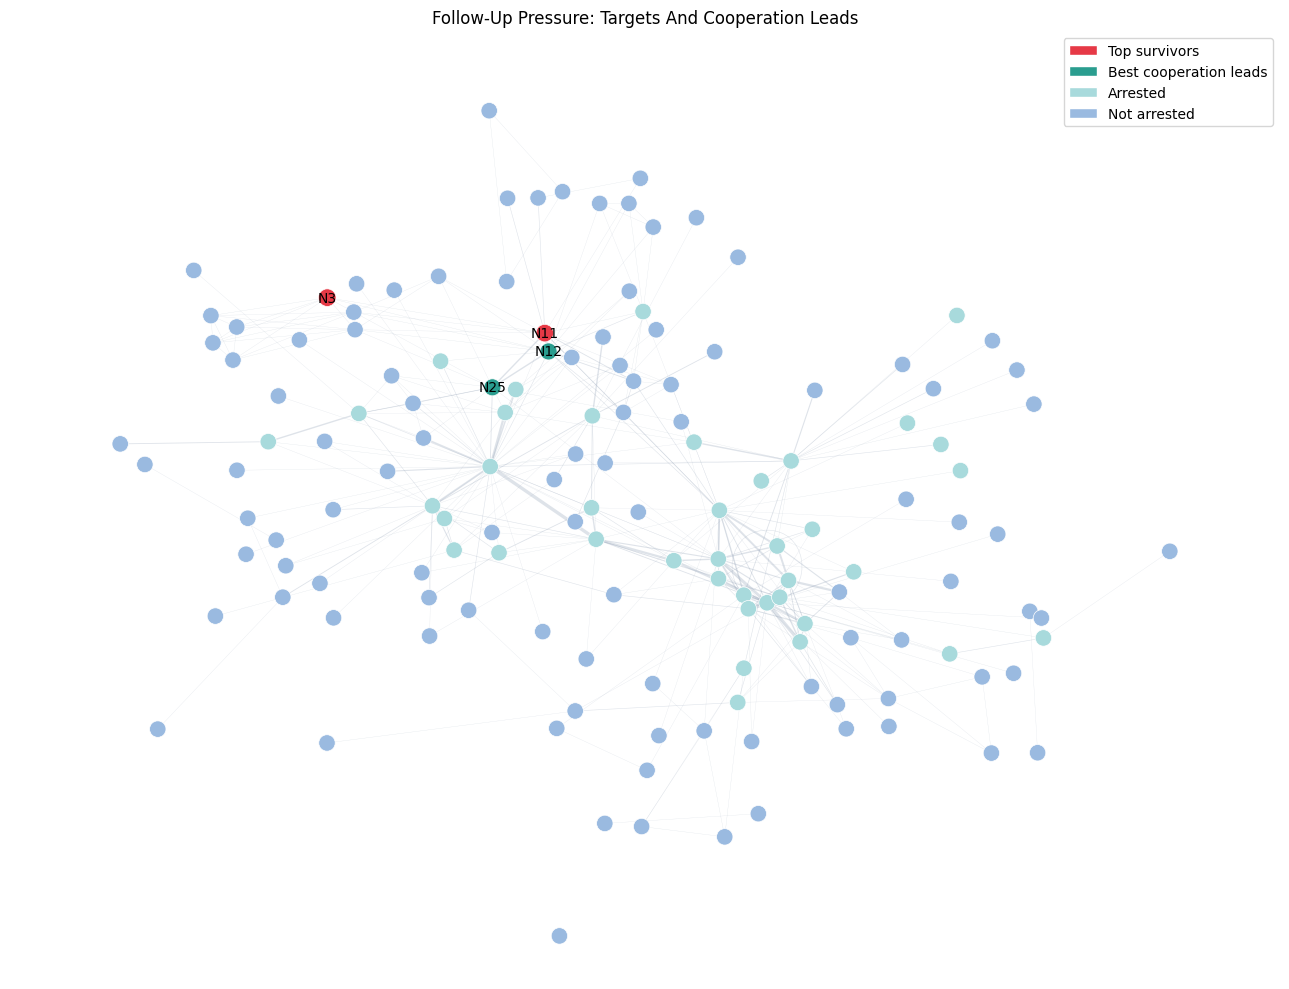

In [137]:
top_survivors = set(surviving_priority.head(2)['Node'])
top_intermediaries = set(arrested_survivor_access.head(2)['Node'])
arrested_nodes = set(full_metrics.loc[full_metrics['arrested'] == 1, 'Node'])

n = full_visual_graph.number_of_nodes()
full_network_position = nx.spring_layout(
    full_visual_graph,
    seed=42,
    weight="weight",
    k=20 / np.sqrt(n),
    iterations=300
)

edge_widths = [
    full_visual_graph[u][v].get('weight', 1) * 0.2
    for u, v in full_visual_graph.edges()
]

node_colors = []
node_sizes = []

for node in full_visual_graph.nodes():
    if node in top_survivors:
        node_colors.append("#e63946")
        node_sizes.append(160)
    elif node in top_intermediaries:
        node_colors.append("#2a9d8f")
        node_sizes.append(150)
    elif node in arrested_nodes:
        node_colors.append("#a8dadc")
        node_sizes.append(140)
    else:
        node_colors.append("#9abae0")
        node_sizes.append(140)

labels = {
    node: node if (node in top_survivors or node in top_intermediaries) else ""
    for node in full_visual_graph.nodes()
}

plt.figure(figsize=(13, 10))

nx.draw_networkx_edges(
    full_visual_graph,
    pos=full_network_position,
    edge_color="#94a3b8",
    alpha=0.30,
    width=edge_widths,
)

nx.draw_networkx_nodes(
    full_visual_graph,
    pos=full_network_position,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="white",
    linewidths=0.5,
)

nx.draw_networkx_labels(
    full_visual_graph,
    pos=full_network_position,
    labels=labels,
    font_size=10,
    font_color="black"
)

legend_elements = [
    Patch(facecolor="#e63946", edgecolor="white", label="Top survivors"),
    Patch(facecolor="#2a9d8f", edgecolor="white", label="Best cooperation leads"),
    Patch(facecolor="#a8dadc", edgecolor="white", label="Arrested"),
    Patch(facecolor="#9abae0", edgecolor="white", label="Not arrested"),
]

plt.legend(handles=legend_elements, loc="upper right")
plt.title("Follow-Up Pressure: Targets And Cooperation Leads")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_intermediaries_network.png')
plt.show()


`N12` and `N25` emerge as the clearest leverage points. They are arrested, but they still sit closest to the two most important surviving targets, which makes them strong candidates for a deal if the goal is to keep pressure on the residual network.


## Story-Aligned Outputs

These exports are organized as briefing assets. Instead of ending with a generic file list, the notebook now packages the evidence needed to tell the story in a report, memo, or presentation: what the network looked like, how badly it fractured, who still matters, and who can expose them.


In [138]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

survivor_target_brief = surviving_priority[
    [
        'Node',
        'family_role',
        'family',
        'current_pagerank',
        'current_weighted_degree',
        'current_component_size',
        'future_arrest_priority_score',
    ]
].head(10).copy()

interrogation_target_brief = arrested_priority[
    [
        'Node',
        'family_role',
        'family',
        'surviving_neighbor_count',
        'cross_family_reach',
        'interrogation_priority_score',
    ]
].head(10).copy()

story_outputs = pd.DataFrame(
    {
        'story_asset': [
            'network_disruption_scorecard',
            'family_disruption_summary',
            'future_arrest_priority_story',
            'interrogation_priority_story',
            'target_access_summary',
            'initial_network_figure',
            'residual_network_figure',
            'targets_and_cooperation_leads_figure',
        ],
        'why_it_matters': [
            'Quantifies how sharply the crackdown reduced cohesion.',
            'Shows which families absorbed the heaviest losses.',
            'Shortlist of the most important surviving actors.',
            'Shortlist of the arrested actors with the highest intelligence value.',
            'Connects cooperation candidates to the highest-priority survivors.',
            'Visual baseline of the organization before intervention.',
            'Visual proof that the surviving network is fragmented.',
            'Single figure that links surviving targets to cooperation leads.',
        ],
        'path': [
            str(REPORTS_DIR / 'network_disruption_scorecard.csv'),
            str(REPORTS_DIR / 'family_disruption_summary.csv'),
            str(REPORTS_DIR / 'future_arrest_priority_story.csv'),
            str(REPORTS_DIR / 'interrogation_priority_story.csv'),
            str(REPORTS_DIR / 'target_access_summary.csv'),
            str(FIGURES_DIR / 'initial_network.png'),
            str(FIGURES_DIR / 'disrupted_graph.png'),
            str(FIGURES_DIR / 'target_intermediaries_network.png'),
        ],
    }
)

story_outputs


,story_asset,why_it_matters,path
0,network_disruption_scorecard,Quantifies how sharply the crackdown reduced c...,/home/ivadi/projects/sicilian_mafia/reports/ne...
1,family_disruption_summary,Shows which families absorbed the heaviest los...,/home/ivadi/projects/sicilian_mafia/reports/fa...
2,future_arrest_priority_story,Shortlist of the most important surviving actors.,/home/ivadi/projects/sicilian_mafia/reports/fu...
3,interrogation_priority_story,Shortlist of the arrested actors with the high...,/home/ivadi/projects/sicilian_mafia/reports/in...
4,target_access_summary,Connects cooperation candidates to the highest...,/home/ivadi/projects/sicilian_mafia/reports/ta...
5,initial_network_figure,Visual baseline of the organization before int...,/home/ivadi/projects/sicilian_mafia/reports/fi...
6,residual_network_figure,Visual proof that the surviving network is fra...,/home/ivadi/projects/sicilian_mafia/reports/fi...
7,targets_and_cooperation_leads_figure,Single figure that links surviving targets to ...,/home/ivadi/projects/sicilian_mafia/reports/fi...


In [139]:
combined_edges.to_csv(PROCESSED_DIR / 'combined_edges.csv', index=False)
full_metrics.to_csv(PROCESSED_DIR / 'node_metrics_full.csv', index=False)
disrupted_metrics.to_csv(PROCESSED_DIR / 'node_metrics_disrupted.csv', index=False)

network_disruption_scorecard.to_csv(REPORTS_DIR / 'network_disruption_scorecard.csv', index=False)
family_disruption_summary.to_csv(REPORTS_DIR / 'family_disruption_summary.csv', index=False)
survivor_target_brief.to_csv(REPORTS_DIR / 'future_arrest_priority_story.csv', index=False)
interrogation_target_brief.to_csv(REPORTS_DIR / 'interrogation_priority_story.csv', index=False)
target_access_summary.to_csv(REPORTS_DIR / 'target_access_summary.csv', index=False)

arrested_priority.to_csv(REPORTS_DIR / 'interrogation_priority.csv', index=False)
surviving_priority.to_csv(REPORTS_DIR / 'arrest_priority.csv', index=False)


## Conclusions

The merged Montagna network begins as a concentrated organization, not a random collection of contacts. Before intervention, it contains `145` actors and `583` directed ties, with a `135`-node largest weak component. The center of gravity is clear: actors such as `N18`, `N47`, and `N68` dominate the baseline ranking and sit inside the dense core that makes the network operationally coherent.

Removing the `41` arrested actors changes that picture dramatically. The residual network falls to `104` actors and `122` directed ties, the number of weak components jumps from `6` to `68`, and isolates rise from `1` to `55`. The intervention therefore did not merely shrink the network; it shattered the giant component and broke much of the original connective tissue.

Even so, the organization does not disappear. It survives in fragments that still preserve investigative value. `N11` and `N3` emerge as the clearest follow-up targets among surviving actors, while `N18`, `N47`, and `N68` remain the most informative arrested actors when the goal is to understand what is left. The access check sharpens that further by pointing to `N12` and `N25` as practical intermediaries to the surviving leadership.

The strategic takeaway is therefore double-edged: the crackdown was highly effective against the original core, but the residual fragments are still legible enough to support the next phase of targeting.
